---
title: "Test"
format: html
---

In [4]:
import pandas as pd
from datetime import datetime
import pytz
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats
from scipy.stats import expon, gamma, lognorm, weibull_min
from scipy.stats import ks_2samp
from scipy.stats import lognorm, kstest

df = pd.read_csv("messages.csv") #load the dataset
#preprocessing
df['Date'] = df['Date'].astype(str).str.slice(0, 19)
df['Date'] = pd.to_datetime(df['Date'], format='%Y-%m-%d %H:%M:%S')
authors = df['Author'].unique()
rename_map = {authors[0]: 'him', authors[1]: 'me'}  # or reverse if needed
df['Author'] = df['Author'].map(rename_map)
cutoff = datetime(2025, 4, 24)
df['period'] = np.where(df['Date'] < cutoff, 'before', 'after')
df = df.sort_values('Date').reset_index(drop=True)
df['prev_author'] = df['Author'].shift()
df['prev_time'] = df['Date'].shift()
df['response_time_hrs'] = (df['Date'] - df['prev_time']).dt.total_seconds() / 3600
df['is_reply'] = df['Author'] != df['prev_author']
df['is_his_reply'] = (df['Author'] == 'him') & df['is_reply']
his_replies = df[df['is_his_reply']].copy()

---

## Introduction: 
Sometimes, you meet someone, and you really like them -- you go on a few dates, and then you have to ask, "Do you want to be more than friends?" And then... you have a probability midterm next Wedneseday. I aim to understand whether a treatment -- "Do you want to be more than friends" talk -- had a statistically significant effect on awkwardness -- which we operationalize as slower response time between messages.


---

## Step 0: Descriptive Data Analysis
- Data pulled from private Discord messages via https://github.com/Tyrrrz/DiscordChatExporter (Doesn't break TOS because it's my own messages)
### Overview


In [5]:
replies = df[df['is_reply']].copy()
avg_response = replies.groupby('Author')['response_time_hrs'].mean()
df['message_length'] = df['Content'].astype(str).str.len()
avg_length = df.groupby('Author')['message_length'].mean()
df['time_since_last'] = (df['Date'] - df['prev_time']).dt.total_seconds() / 60  # in minutes
df['double_text'] = (df['Author'] == df['prev_author']) & (df['time_since_last'] > 10)
double_texts = df.groupby('Author')['double_text'].sum()
summary_df = pd.DataFrame({
    'response time (hrs)': avg_response,
    'avg message length': avg_length,
    'double text count': double_texts
}).reset_index()

summary_df

,Author,response time (hrs),avg message length,double text count
0,him,0.111469,35.102881,66
1,me,0.270872,28.239297,24


---
### Aggregate Response Time over Time


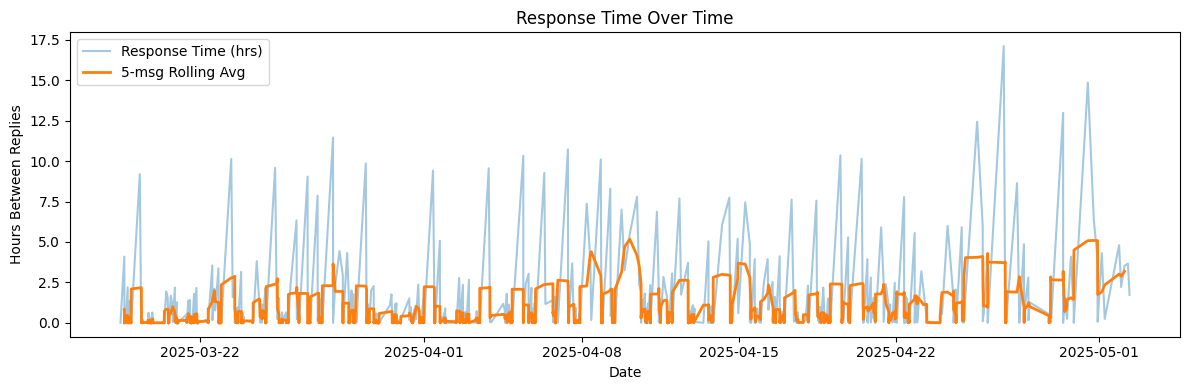

In [6]:
replies['rolling_avg'] = replies['response_time_hrs'].rolling(window=5, center=True).mean()
plt.figure(figsize=(12, 4))
sns.lineplot(data=replies, x='Date', y='response_time_hrs', label='Response Time (hrs)', alpha=0.4)
sns.lineplot(data=replies, x='Date', y='rolling_avg', label='5-msg Rolling Avg', linewidth=2)
plt.title("Response Time Over Time")
plt.ylabel("Hours Between Replies")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

---

### Response Time by Author over Time

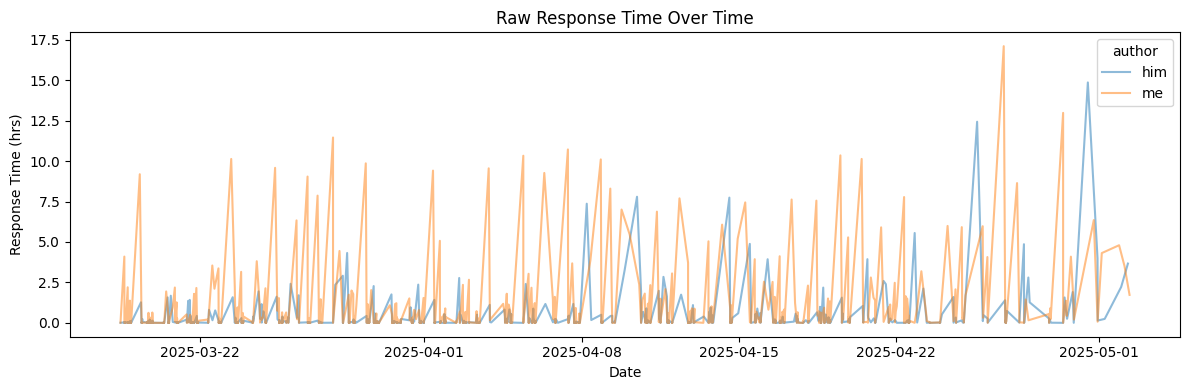

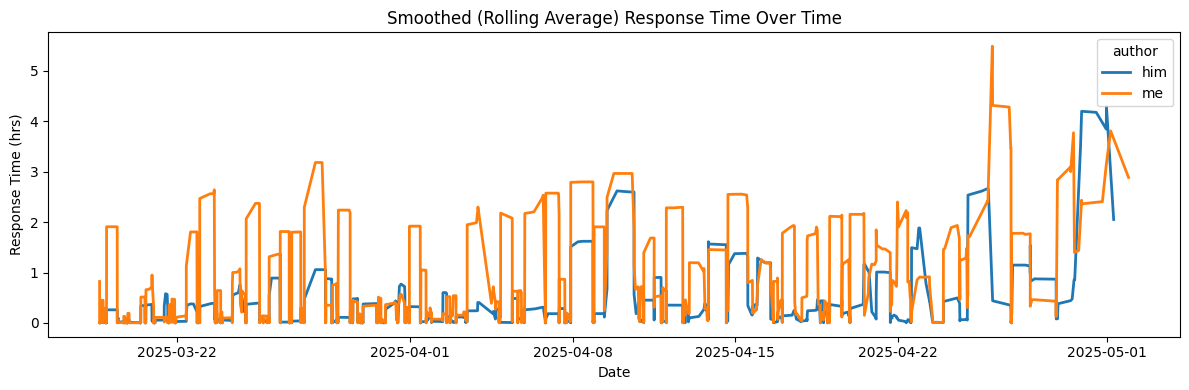

In [7]:
replies['author'] = replies['Author']  # for legend label
replies['rolling_avg'] = (
    replies.groupby('author')['response_time_hrs']
    .transform(lambda x: x.rolling(window=5, center=True).mean())
)
plt.figure(figsize=(12, 4))
sns.lineplot(data=replies, x='Date', y='response_time_hrs', hue='author', alpha=0.5)
plt.title("Raw Response Time Over Time")
plt.ylabel("Response Time (hrs)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()
plt.figure(figsize=(12, 4))
sns.lineplot(data=replies, x='Date', y='rolling_avg', hue='author', linewidth=2)
plt.title("Smoothed (Rolling Average) Response Time Over Time")
plt.ylabel("Response Time (hrs)")
plt.xlabel("Date")
plt.tight_layout()
plt.show()

---

## Obtaining priors => What is the reply distribution before the treatment?
- Because we are measuring delays between replies, we initially try to model response times as exponentially distributed, which models the time between individual events, but is also memoryless --- assumes that the time it takes for another event to occur is independent of what has happened before, more specifically, that the events are generated via Poisson processes. 


### Determining prior distribution
 First, let's figure out if our data actually is expontentially distributed (though this isn't relevant to the course material yet, I'm just curious because I'm fairly sure it doesn't make sense for response times to be memoryless. Though maybe that'd be a interesting way to detect whether people are just posting just to post versus actually having a conversation with someone else). 

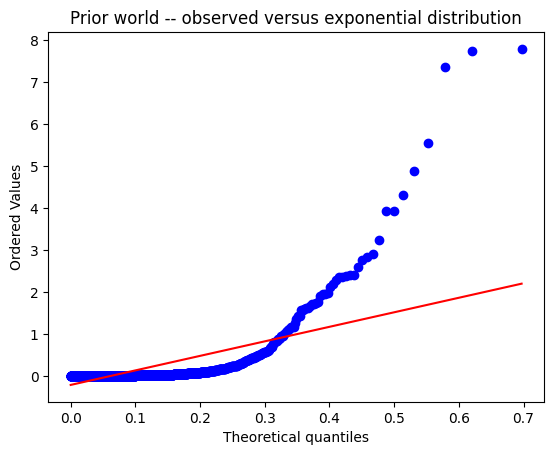

In [8]:
before_data = his_replies[his_replies['period'] == 'before']['response_time_hrs'].dropna()
lambda_before = 1 / before_data.mean()
stats.probplot(before_data, dist=stats.expon(scale=1/lambda_before), plot=plt)
plt.title("Prior world -- observed versus exponential distribution")
plt.show()


### Interpretation 
 Quantile-quantile plot, this plot compares the quantiles of our data with the quantiles of some theoretical distribution (in this case, exponential distribution). This is a 'heavy right tail' pattern -- first, we start close to the theoretical line (in other words, the short delays, quick replies are roughly exponential). The dip below the line -- so medium delays are more uniform than expected if they were expontentially distributed. But then, we go way above the line -- which indicates that the longer, rarer delays are much more extreme than expected. Anyways this isn't very good, but that's real world data for you. 

 ---

### Other distributions
How can we tell if one model fits better than another? In this case, we check the probability density functions for a bunch of candidate distributions. Because time is continuous, each random variable has a Probability Density Function, compared to discrete random variables, which have Probability Mass Functions. Probability Density Functions tell us the likelihood that a random variable takes on a value, instead of the probability of the random variable taking on any value.

---

#### Gamma Distribution

The Gamma distribution is often used to model **waiting times** until multiple events happen. It's flexible in shape and can capture skewed, continuous behaviors. It’s defined by a **shape** and **scale** parameter:
- When the shape is 1, it reduces to an Exponential distribution.
- When the shape is large, it starts to resemble a Normal distribution.

It’s useful when the process has **accumulated delays**, like “how long until three replies happen.”

---

#### Log-Normal Distribution

The Log-Normal distribution models variables that are **skewed right** (long tail) and **bounded below by 0**. It arises when the **logarithm of the variable is normally distributed**.

It’s a great fit for human-like timing behaviors—e.g., people usually respond fast, but sometimes take *much* longer. Log-normal is especially good when you see many quick replies and a few long gaps.

---

#### Weibull Distribution

The Weibull distribution is often used in **reliability and survival analysis**. It can model increasing, decreasing, or constant failure rates depending on its **shape parameter**.

In social timing, it can capture whether reply delays become **more or less likely over time**—for example, someone who’s more likely to ghost the longer they wait.



C:\Users\emzou\AppData\Local\Packages\PythonSoftwareFoundation.Python.3.10_qbz5n2kfra8p0\LocalCache\local-packages\Python310\site-packages\scipy\stats\_continuous_distns.py:2757: RuntimeWarning: divide by zero encountered in power
  return c*pow(x, c-1)*np.exp(-pow(x, c))


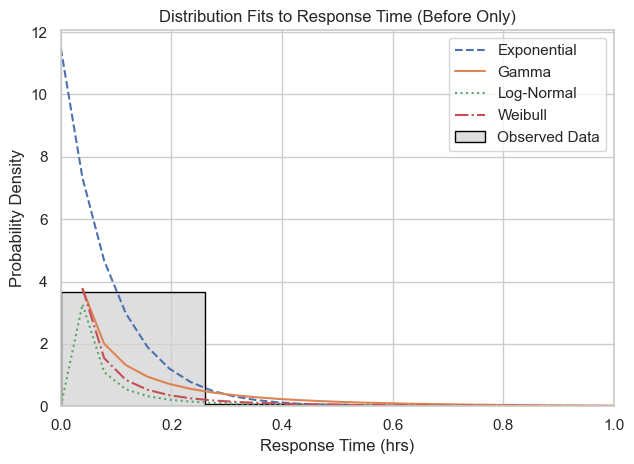

In [9]:
#round up millisecoond differences 
before_data = before_data.copy()
before_data[before_data == 0] = 1 / 3600  # 1 second = 0.000277... hrs
fit_expon = expon.fit(before_data, floc=0)
fit_gamma = gamma.fit(before_data, floc=0)
fit_lognorm = lognorm.fit(before_data, floc=0)
fit_weibull = weibull_min.fit(before_data, floc=0)
x = np.linspace(0, before_data.max(), 200)
sns.set(style="whitegrid")
sns.histplot(before_data, stat="density", bins=30, color="lightgray", edgecolor="black", label="Observed Data")
plt.plot(x, expon.pdf(x, *fit_expon), label="Exponential", linestyle='--')
plt.plot(x, gamma.pdf(x, *fit_gamma), label="Gamma", linestyle='-')
plt.plot(x, lognorm.pdf(x, *fit_lognorm), label="Log-Normal", linestyle=':')
plt.plot(x, weibull_min.pdf(x, *fit_weibull), label="Weibull", linestyle='-.')
plt.xlabel("Response Time (hrs)")
plt.ylabel("Probability Density")
plt.title("Distribution Fits to Response Time (Before Only)")
plt.legend()
plt.tight_layout()
plt.yscale("linear")  # or try 'log' to better see tails
plt.xlim(0, 1)
plt.show()

---

### Distribution Fit 
#### AIC (Akaike Information Criterion)

AIC is a model comparison metric that balances fit and complexity. It rewards models that explain the data well but penalizes those that use too many parameters. Lower AIC values indicate better models. It doesn't say how good a model is in absolute terms, just how it compares to others on the same data.


In [10]:
def compute_aic(log_likelihood, k):
    return 2 * k - 2 * log_likelihood

def compute_log_likelihood(distribution, params):
    return np.sum(distribution.logpdf(before_data, *params))

aics = {}

# Exponential
ll_exp = compute_log_likelihood(expon, fit_expon)
aics["Exponential"] = compute_aic(ll_exp, k=1)  # only scale param

# Gamma
ll_gamma = compute_log_likelihood(gamma, fit_gamma)
aics["Gamma"] = compute_aic(ll_gamma, k=2)

# Log-Normal
ll_lognorm = compute_log_likelihood(lognorm, fit_lognorm)
aics["Log-Normal"] = compute_aic(ll_lognorm, k=2)

# Weibull
ll_weibull = compute_log_likelihood(weibull_min, fit_weibull)
aics["Weibull"] = compute_aic(ll_weibull, k=2)
for name, aic in sorted(aics.items(), key=lambda x: x[1]):
    print(f"{name}: AIC = {aic:.2f}")

Log-Normal: AIC = -12564.58
Weibull: AIC = -11740.66
Gamma: AIC = -10645.79
Exponential: AIC = -5968.29


### Result:
The Log-Normal distribution is the best model for our prior world. 

---

## Inference 
The goal of general inference is to change a belief distribution of random variables based on some observations. We want to know if we expect that our new observations (the post-treatment data) come from a different statistical distribution. 


#### What is a CDF?

A **Cumulative Distribution Function (CDF)** tells us the probability that a random variable is **less than or equal to** a given value.

For example:  
> If the CDF at 3 hours is 0.80, that means 80% of replies come within 3 hours.

The CDF always:
- Starts at 0 (nothing has happened yet)
- Grows smoothly to 1 (100% of outcomes fall below some high-enough value)
- Is non-decreasing and continuous for continuous variables

---

#### Why do we use it?

The **CDF gives a complete picture** of a distribution — not just the most likely value (mode) or average (mean), but how values are **accumulated** over time or space. It's especially useful when comparing two distributions because it captures **both central tendency and tail behavior**.

In the **Kolmogorov–Smirnov (K-S) test**, we compare two CDFs to see how far apart they are at any point. The K-S statistic (D) is the **maximum vertical distance** between them.

---

#### When should we use CDFs?

- When comparing distributions (e.g., pre/post treatment)
- When calculating probabilities like “how likely is a response within 5 hours?”
- When visualizing the *full behavior* of skewed or long-tailed distributions

#### Interpreting Results 
The K-S statistic is the maximum distance between the two CDFs (cumulative distribution functions), the stat (D) ranges from 0 to 1
D = 0 → the two distributions are identical
D > 0.2 → usually considered a substantial difference
D > 0.3 → strong evidence the two distributions are not the same

If p < 0.05, reject null => the after-data likely does not come from the before-distribution → treatment had an effect
If p > 0.05, fail to reject the null => things might still be the same



In [11]:
shape, loc, scale = fit_lognorm
after_data = his_replies[his_replies['period'] == 'after']['response_time_hrs'].dropna()
ks_stat, p_val = kstest(after_data, 'lognorm', args=(shape, loc, scale))
print(f"KS stat = {ks_stat:.4f}, p = {p_val:.4f}")

KS stat = 0.3673, p = 0.0000



### Result
 KS Stat being 0.3675, as well as p-value is 0, strongly indicates that the treatment had a statistically significant effect. 
### Validation
As a robustness check, let's do a permutation test to see if we can get a higher K-S stat just from randomly splitting the data. 

In [12]:
ks_stats = []
n_trials = 1000
observed_d = 0.3675
data = before_data.to_numpy()
for _ in range(n_trials):
    np.random.shuffle(data)
    split = len(data) // 2
    group1 = data[:split]
    group2 = data[split:]
    ks_stat, _ = ks_2samp(group1, group2)
    ks_stats.append(ks_stat)

p_perm = np.mean(np.array(ks_stats) >= observed_d)
print(f"Empirical p-value from permutation = {p_perm:.4f}")

Empirical p-value from permutation = 0.0000





## Conclusion
Behavioral data is rarely so conclusive, but it is undeniable.... However, this is useful for Bayesian Inference later, if we keep on talking, and get back to a normal state (and ideally also get back into an awkward state) just to verify how good the model is,  and then if I wanted to predict whether we were in 'awkward' or 'normal' mode. But the numbers say... we must stay only friends. 